# Notebook pour l'article : Grover pondéré + qubit auxiliaire

Ce notebook reprend la logique du notebook `grover_with_auxilliary_qubits.ipynb` : on part d'un Grover avec un qubit auxiliaire initialisé par une rotation $R_y(\phi)$, puis on contrôle l'oracle par l'état $|0\rangle$ de ce qubit auxiliaire.

L'objectif ici est de l'adapter à l'article **“Quantum search algorithm on weighted databases”** :

- base de données pondérée : $p_k = |P(k)|^2$ ;
- coût classique local : $s_k \sim 1/p_k$ ;
- coût Grover local estimé : $T_k \sim 1/\widetilde\Delta_k$, avec $\widetilde\Delta_k = \sqrt{p_k-p_k^2}$ ;
- exemples reproduits : base uniforme et distribution de type état cohérent tronqué ;
- ajout du qubit auxiliaire pour rendre le nombre d'itérations entier et éviter le dépassement de l'optimum.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

Matplotlib is building the font cache; this may take a moment.


## 1. Fonctions générales

Dans l'article, l'état de base de données est

$$
|D\rangle = \sum_k P(k)|k\rangle, \qquad p_k = |P(k)|^2.
$$

Pour une cible $|k\rangle$, l'évolution Grover $G = U_D U_k$ peut s'écrire dans le sous-espace engendré par $|D\rangle$ et $|k\rangle$ :

$$
G^r|D\rangle = a_r|D\rangle + b_r|k\rangle.
$$

La récurrence utilisée dans l'article est :

$$
\begin{aligned}
a_r &= (1-4|P(k)|^2)a_{r-1} - 2P(k)^* b_{r-1},\\
b_r &= b_{r-1} + 2P(k)a_{r-1}.
\end{aligned}
$$

In [2]:
def grover_recurrence(Pk, r_max=80):
    """Calcule les suites a_r et b_r de l'article pour une amplitude cible P(k)."""
    Pk = complex(Pk)
    a = np.zeros(r_max + 1, dtype=complex)
    b = np.zeros(r_max + 1, dtype=complex)

    # L'article trace les amplitudes après la première application de G.
    a[0] = 1 - 4 * abs(Pk)**2
    b[0] = 2 * Pk

    for r in range(1, r_max + 1):
        a[r] = (1 - 4 * abs(Pk)**2) * a[r-1] - 2 * np.conj(Pk) * b[r-1]
        b[r] = b[r-1] + 2 * Pk * a[r-1]
    return a, b


def delta_tilde_from_p(p):
    """Delta_tilde = sqrt(p - p^2)."""
    p = np.asarray(p, dtype=float)
    return np.sqrt(np.maximum(p - p**2, 0.0))


def classical_steps(p):
    """Nombre d'essais classique local ~ 1/p."""
    p = np.asarray(p, dtype=float)
    return np.where(p > 0, 1 / p, np.inf)


def grover_steps_estimate(p):
    """Nombre d'itérations Grover local ~ 1/Delta_tilde, sans le facteur constant pi."""
    d = delta_tilde_from_p(p)
    return np.where(d > 0, 1 / d, np.inf)


def exact_auxiliary_parameters(p):
    """
    Paramètres du notebook au qubit auxiliaire.

    p      : probabilité de succès initiale.
    k      : nombre d'itérations idéal, généralement non entier.
    kprime : entier choisi pour Grover exact.
    pprime : probabilité effective requise.
    phi    : angle Ry(phi) tel que p*cos^2(phi/2)=pprime.
    """
    p = float(p)
    if not (0 < p < 1):
        raise ValueError("p doit être dans ]0,1[.")
    k = np.pi / (4 * np.arcsin(np.sqrt(p))) - 0.5
    kprime = int(np.ceil(k))
    pprime = np.sin(np.pi / (4 * (kprime + 0.5)))**2
    phi = 2 * np.arccos(np.sqrt(pprime / p))
    return dict(p=p, k=k, kprime=kprime, pprime=pprime, phi=phi)


def grover_success_probability(p, r):
    """Probabilité de succès standard après r itérations, dans le modèle 2D."""
    theta = np.arcsin(np.sqrt(p))
    return np.sin((2 * r + 1) * theta)**2

## 2. Cas uniforme : retour au Grover standard

Pour une base non structurée uniforme de taille $N$, on a $P(k)=1/\sqrt{N}$, donc $p_k=1/N$.

L'article retrouve alors :

$$
\widetilde\Delta = \sqrt{\frac{1}{N}-\frac{1}{N^2}} \simeq \frac{1}{\sqrt{N}},
$$

ce qui donne le coût Grover $O(\sqrt{N})$, contre $O(N)$ classiquement.

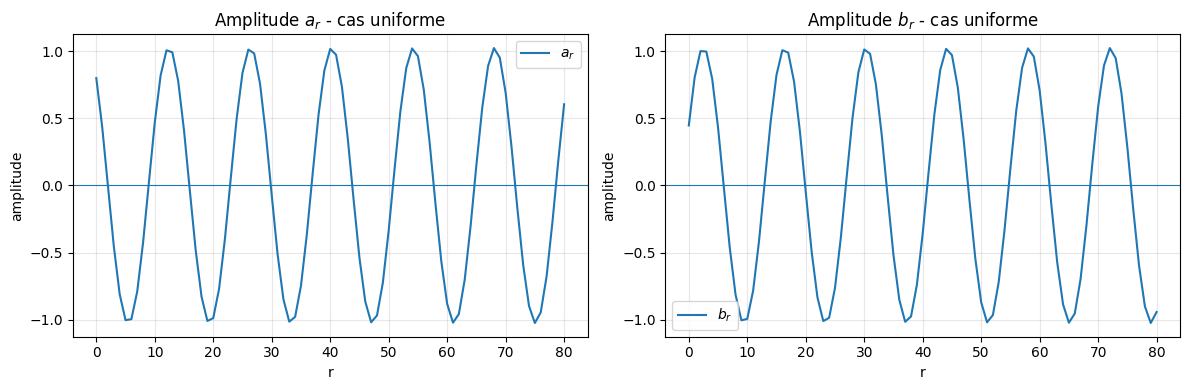

N = 20
p = 0.05
coût classique ~ 20.0
coût Grover estimé ~ 4.588314677411236
sqrt(N) = 4.47213595499958


In [3]:
N = 20
Pk = 1 / np.sqrt(N)
a, b = grover_recurrence(Pk, r_max=80)
r = np.arange(len(a))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(r, a.real, label=r"$a_r$")
axes[0].axhline(0, linewidth=0.8)
axes[0].set_title("Amplitude $a_r$ - cas uniforme")
axes[0].set_xlabel("r")
axes[0].set_ylabel("amplitude")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(r, b.real, label=r"$b_r$")
axes[1].axhline(0, linewidth=0.8)
axes[1].set_title("Amplitude $b_r$ - cas uniforme")
axes[1].set_xlabel("r")
axes[1].set_ylabel("amplitude")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

p_uniform = 1 / N
print("N =", N)
print("p =", p_uniform)
print("coût classique ~", classical_steps(p_uniform))
print("coût Grover estimé ~", grover_steps_estimate(p_uniform))
print("sqrt(N) =", np.sqrt(N))

## 3. Base pondérée de type état cohérent tronqué

L'article considère ensuite un état cohérent tronqué :

$$
|\alpha'\rangle = \mathcal N_q \sum_{q=q_1}^{q_1+N} e^{-|\alpha|^2/2}\frac{\alpha^q}{\sqrt{q!}}|q\rangle.
$$

La probabilité normalisée est proportionnelle à :

$$
p_q \propto \frac{|\alpha|^{2q}}{q!}, \qquad q_1 \le q \le q_1+N.
$$

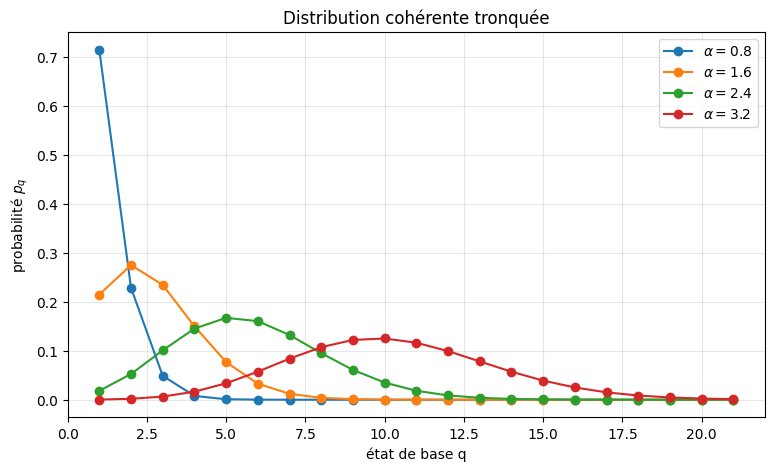

In [4]:
def coherent_truncated_distribution(alpha, q1=1, N=20):
    """Distribution de probabilité normalisée d'un état cohérent tronqué."""
    qs = np.arange(q1, q1 + N + 1)
    log_w = 2 * qs * np.log(abs(alpha)) - np.array([math.lgamma(q + 1) for q in qs])
    # Stabilisation numérique
    weights = np.exp(log_w - np.max(log_w))
    probs = weights / weights.sum()
    amplitudes = np.sqrt(probs)
    return qs, probs, amplitudes

alphas = [0.8, 1.6, 2.4, 3.2]
q1 = 1
N_coh = 20

plt.figure(figsize=(9, 5))
for alpha in alphas:
    qs, probs, _ = coherent_truncated_distribution(alpha, q1=q1, N=N_coh)
    plt.plot(qs, probs, marker='o', label=fr"$\alpha={alpha}$")
plt.title("Distribution cohérente tronquée")
plt.xlabel("état de base q")
plt.ylabel("probabilité $p_q$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 4. Comparaison locale : classique vs Grover pondéré

Pour chaque cible $q$, on compare :

- classique : $s_q \sim 1/p_q$ ;
- Grover pondéré : $t_q \sim 1/\sqrt{p_q-p_q^2}$.

Quand $p_q$ est petit, le coût Grover se comporte comme $1/\sqrt{p_q}$, ce qui donne l'analogue du gain quadratique.

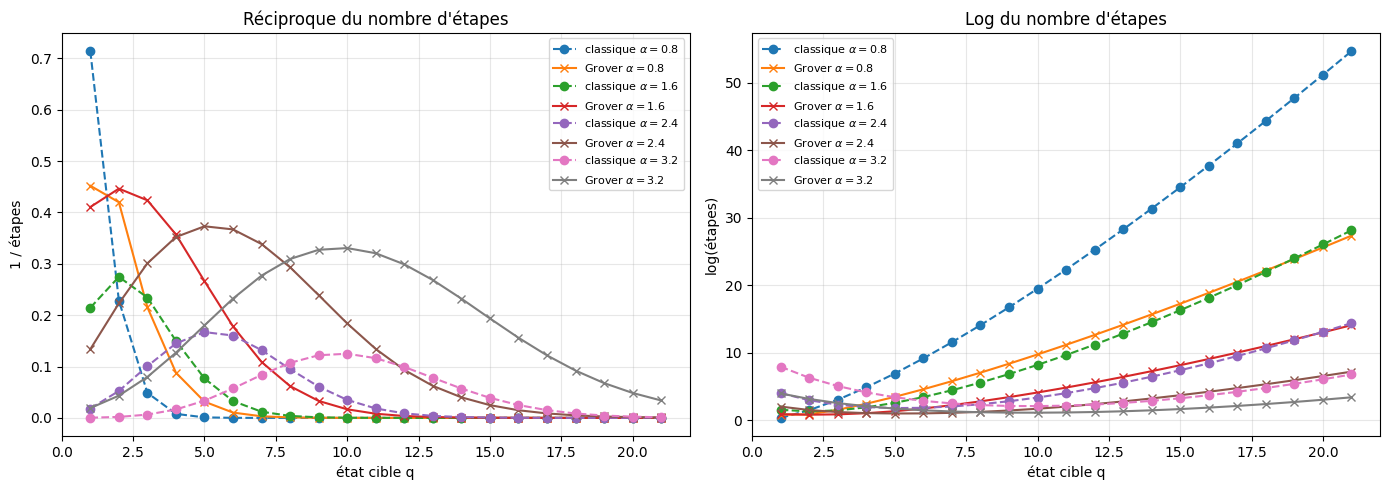

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for alpha in alphas:
    qs, probs, _ = coherent_truncated_distribution(alpha, q1=q1, N=N_coh)
    reciprocal_classical = probs
    reciprocal_grover = delta_tilde_from_p(probs)
    axes[0].plot(qs, reciprocal_classical, marker='o', linestyle='--', label=fr"classique $\alpha={alpha}$")
    axes[0].plot(qs, reciprocal_grover, marker='x', label=fr"Grover $\alpha={alpha}$")

    axes[1].plot(qs, np.log(classical_steps(probs)), marker='o', linestyle='--', label=fr"classique $\alpha={alpha}$")
    axes[1].plot(qs, np.log(grover_steps_estimate(probs)), marker='x', label=fr"Grover $\alpha={alpha}$")

axes[0].set_title("Réciproque du nombre d'étapes")
axes[0].set_xlabel("état cible q")
axes[0].set_ylabel("1 / étapes")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].set_title("Log du nombre d'étapes")
axes[1].set_xlabel("état cible q")
axes[1].set_ylabel("log(étapes)")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Ajout du qubit auxiliaire : rendre Grover exact

Le notebook envoyé utilise un qubit auxiliaire préparé par :

$$
R_y(\phi)|0\rangle = \cos(\phi/2)|0\rangle + \sin(\phi/2)|1\rangle.
$$

Si l'oracle ne marque la cible que lorsque l'auxiliaire est en $|0\rangle$, la probabilité effective de succès devient :

$$
p_{\mathrm{eff}} = p\cos^2(\phi/2).
$$

On choisit alors $\phi$ pour transformer $p$ en une probabilité $p'$ compatible avec un nombre entier $k'$ d'itérations :

$$
p' = \sin^2\left(\frac{\pi}{4(k'+1/2)}\right), \qquad
\phi = 2\arccos\sqrt{\frac{p'}{p}}.
$$

In [6]:
# Exemple : une cible dans une base uniforme de 6 qubits, comme dans le notebook envoyé.
n_qubits = 6
M = 1
N = 2**n_qubits
p = M / N
params = exact_auxiliary_parameters(p)
params

{'p': 0.015625,
 'k': np.float64(5.766749819872207),
 'kprime': 6,
 'pprime': np.float64(0.014529091286973985),
 'phi': np.float64(0.5360678899560556)}

Probabilité initiale p = 0.015625
Itérations idéales non entières k = 5.766749819872207
Itérations entières k' = 6
Probabilité corrigée p' = 0.014529091286973985
Angle phi = 0.5360678899560556 rad
Vérification p*cos^2(phi/2) = 0.014529091286973985


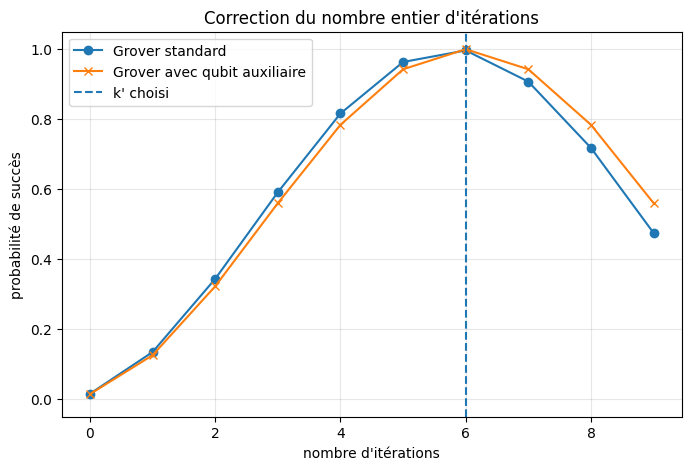

In [7]:
print("Probabilité initiale p =", params['p'])
print("Itérations idéales non entières k =", params['k'])
print("Itérations entières k' =", params['kprime'])
print("Probabilité corrigée p' =", params['pprime'])
print("Angle phi =", params['phi'], "rad")
print("Vérification p*cos^2(phi/2) =", p * np.cos(params['phi']/2)**2)

r_values = np.arange(params['kprime'] + 4)
probs_standard = [grover_success_probability(p, r) for r in r_values]
probs_aux = [grover_success_probability(params['pprime'], r) for r in r_values]

plt.figure(figsize=(8, 5))
plt.plot(r_values, probs_standard, marker='o', label="Grover standard")
plt.plot(r_values, probs_aux, marker='x', label="Grover avec qubit auxiliaire")
plt.axvline(params['kprime'], linestyle='--', label="k' choisi")
plt.title("Correction du nombre entier d'itérations")
plt.xlabel("nombre d'itérations")
plt.ylabel("probabilité de succès")
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 6. Variante pondérée + qubit auxiliaire

On peut appliquer la même correction localement à une cible pondérée $q$ :

1. on prend $p = p_q$ ;
2. on calcule $k$, $k'$, $p'$ et $\phi$ ;
3. l'oracle est contrôlé par l'auxiliaire en $|0\rangle$ ;
4. après $k'$ itérations, la probabilité de succès atteint théoriquement 1 dans le modèle idéal à deux dimensions.

alpha = 1.6, cible q = 3
p cible = 0.23426989478346114
k idéal = 1.0545160635797965
k' entier = 2
p' corrigée = 0.09549150281252627
phi = 1.7566378058704324 rad
succès théorique à k' = 1.0


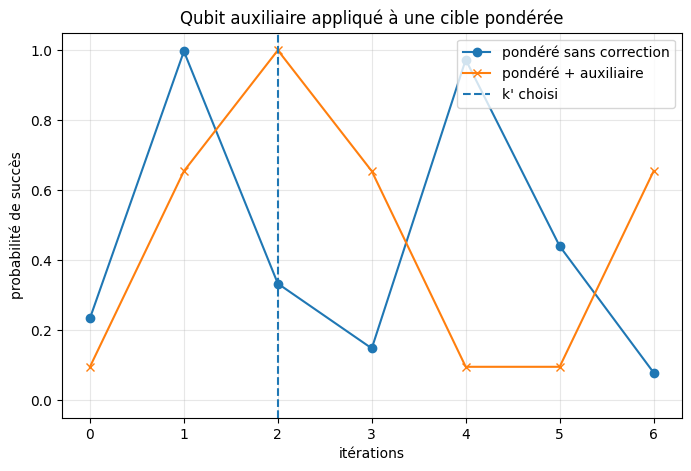

In [8]:
alpha = 1.6
qs, probs, amps = coherent_truncated_distribution(alpha, q1=1, N=20)
q_target = 3
idx = np.where(qs == q_target)[0][0]
p_target = probs[idx]
aux_weighted = exact_auxiliary_parameters(p_target)

print(f"alpha = {alpha}, cible q = {q_target}")
print("p cible =", p_target)
print("k idéal =", aux_weighted['k'])
print("k' entier =", aux_weighted['kprime'])
print("p' corrigée =", aux_weighted['pprime'])
print("phi =", aux_weighted['phi'], "rad")
print("succès théorique à k' =", grover_success_probability(aux_weighted['pprime'], aux_weighted['kprime']))

r_values = np.arange(aux_weighted['kprime'] + 5)
probs_without_aux = [grover_success_probability(p_target, r) for r in r_values]
probs_with_aux = [grover_success_probability(aux_weighted['pprime'], r) for r in r_values]

plt.figure(figsize=(8, 5))
plt.plot(r_values, probs_without_aux, marker='o', label="pondéré sans correction")
plt.plot(r_values, probs_with_aux, marker='x', label="pondéré + auxiliaire")
plt.axvline(aux_weighted['kprime'], linestyle='--', label="k' choisi")
plt.title("Qubit auxiliaire appliqué à une cible pondérée")
plt.xlabel("itérations")
plt.ylabel("probabilité de succès")
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 7. Cellule optionnelle Qiskit : squelette de circuit

Cette cellule reprend l'esprit du notebook envoyé. Elle n'est pas nécessaire pour les figures numériques ci-dessus, mais elle donne la structure à utiliser dans un vrai circuit :

- registre de recherche `q` ;
- registre auxiliaire `aux` ;
- initialisation `H` sur `q` ou préparation pondérée plus générale ;
- rotation `Ry(phi)` sur `aux` ;
- oracle contrôlé par `aux == 0` ;
- diffuseur sur le registre de recherche ;
- répétition `kprime` fois.

In [9]:
# Cette cellule est optionnelle : elle s'exécute seulement si Qiskit est installé.
try:
    from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
    from qiskit.circuit.library import MCMTGate, ZGate

    def oracle_uniform_marked_state(marked_state):
        if isinstance(marked_state, str):
            marked_states = [marked_state]
        else:
            marked_states = list(marked_state)

        num_qubits = len(marked_states[0])
        qc = QuantumCircuit(num_qubits, name="Oracle")
        for target in marked_states:
            rev_target = target[::-1]
            zero_inds = [i for i, bit in enumerate(rev_target) if bit == "0"]
            qc.x(zero_inds)
            qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
            qc.x(zero_inds)
        return qc

    def diffusion_uniform(num_qubits):
        qc = QuantumCircuit(num_qubits, name="Diffusion")
        qc.h(range(num_qubits))
        qc.x(range(num_qubits))
        qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
        qc.x(range(num_qubits))
        qc.h(range(num_qubits))
        return qc

    marked_states = ["111011"]
    n = len(marked_states[0])
    p = len(marked_states) / 2**n
    params = exact_auxiliary_parameters(p)
    kprime = params["kprime"]
    phi = params["phi"]

    q = QuantumRegister(n, "q")
    aux = QuantumRegister(1, "aux")
    c = ClassicalRegister(n, "c")
    qc = QuantumCircuit(q, aux, c)

    qc.h(q)
    qc.ry(phi, aux[0])

    oracle_gate = oracle_uniform_marked_state(marked_states).to_gate().control(1, ctrl_state="0")
    diffusion_gate = diffusion_uniform(n).to_gate()

    for _ in range(kprime):
        qc.append(oracle_gate, [aux[0]] + list(q))
        qc.append(diffusion_gate, q)

    qc.measure(q, c)
    display(qc.draw(output="text"))

except Exception as exc:
    print("Qiskit n'est pas disponible ou le dessin du circuit a échoué.")
    print(type(exc).__name__ + ":", exc)

Qiskit n'est pas disponible ou le dessin du circuit a échoué.
ModuleNotFoundError: No module named 'qiskit'


## 8. Conclusion pour l'article

Ce notebook montre trois points utiles pour l'article :

1. **Le modèle pondéré** remplace la probabilité uniforme $1/N$ par une probabilité cible $p_k$.
2. **L'estimation Grover** devient locale : le coût varie comme $1/\sqrt{p_k-p_k^2}$, au lieu du coût classique $1/p_k$.
3. **Le qubit auxiliaire** permet de corriger la probabilité de départ vers une valeur $p'$ compatible avec un nombre entier d'itérations, ce qui rend l'amplification quasi-déterministe dans le modèle idéal.

À intégrer dans l'article : le qubit auxiliaire n'est pas nécessaire pour montrer le gain pondéré, mais il est très utile pour éviter l'overshoot lorsque le nombre optimal d'itérations n'est pas entier.